Raw neural shape: (106087, 175)
Raw syllables shape: (106087,)
Train timepoints: 79565
Test timepoints: 26522
PC data shape: (106087, 10)
Explained variance ratio (train PCA): [0.03201659 0.02786422 0.02319822 0.02095216 0.01943406 0.01773685
 0.01685271 0.0163333  0.0157344  0.01520637]
Cumulative explained variance: [0.03201659 0.05988082 0.08307903 0.10403119 0.12346525 0.14120209
 0.1580548  0.1743881  0.1901225  0.20532887]
Transition split index: 79564
Train transitions: 79564
Test transitions: 26522
Using device: cuda
Epoch 000 | Train loss: 3.617397 | Test loss (teacher forced): 1.624457
Epoch 020 | Train loss: 1.311775 | Test loss (teacher forced): 0.627112
Epoch 040 | Train loss: 0.165676 | Test loss (teacher forced): 0.101487
Epoch 060 | Train loss: 0.062496 | Test loss (teacher forced): 0.044594
Epoch 080 | Train loss: 0.034186 | Test loss (teacher forced): 0.026984
Epoch 100 | Train loss: 0.026037 | Test loss (teacher forced): 0.021379
Epoch 120 | Train loss: 0.022334 | Te

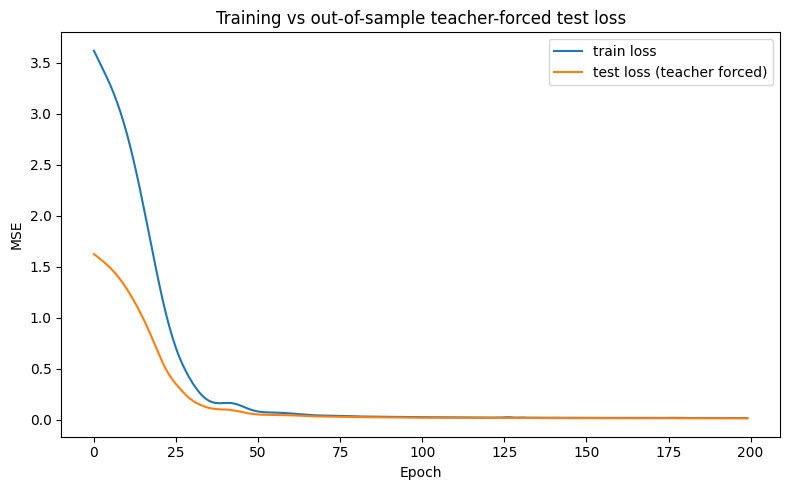

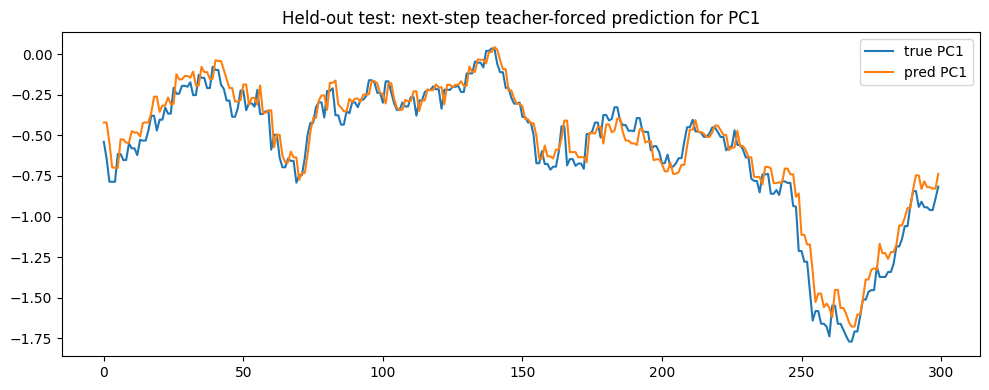

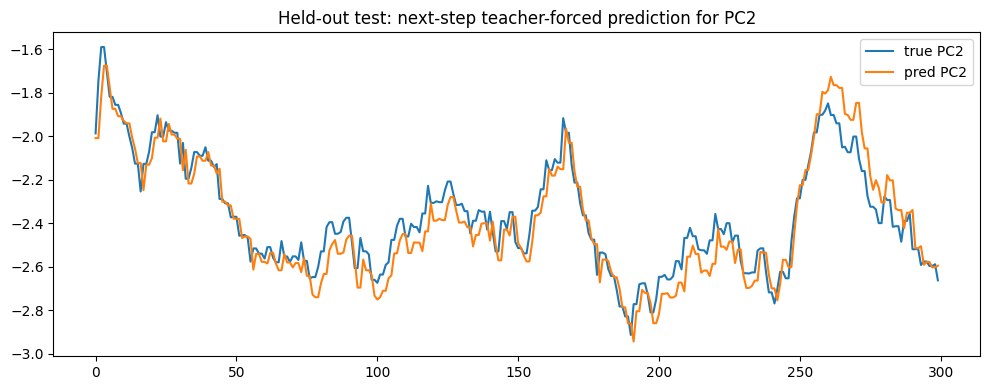

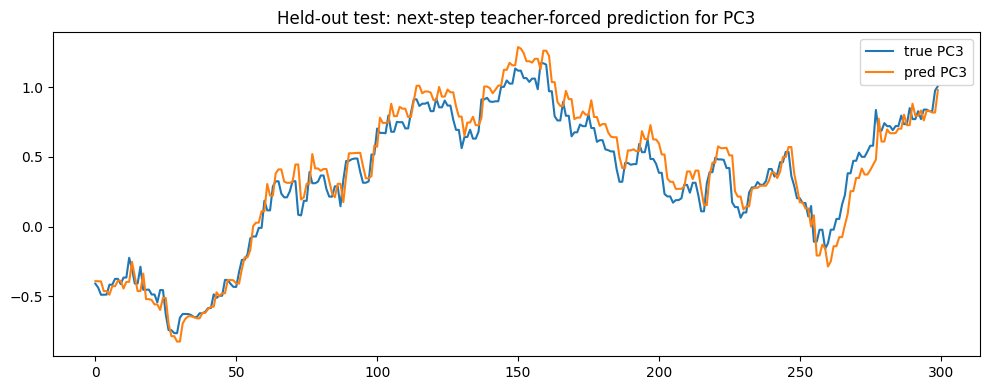

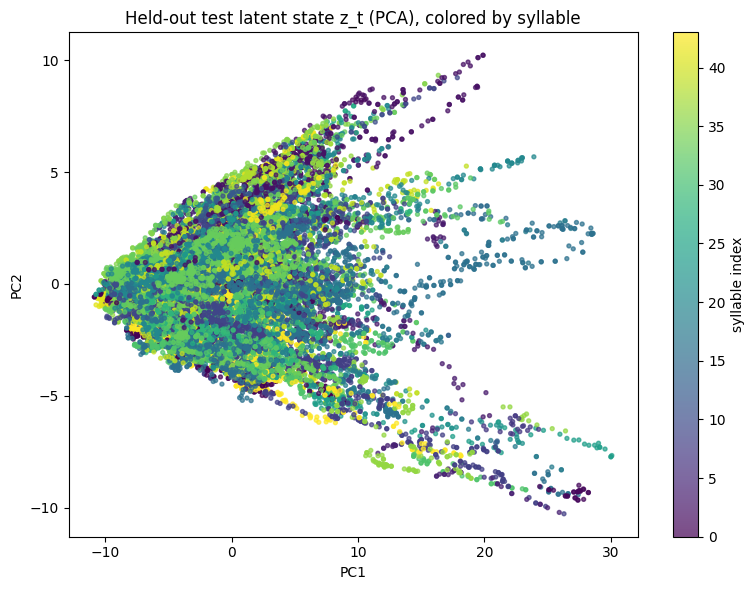

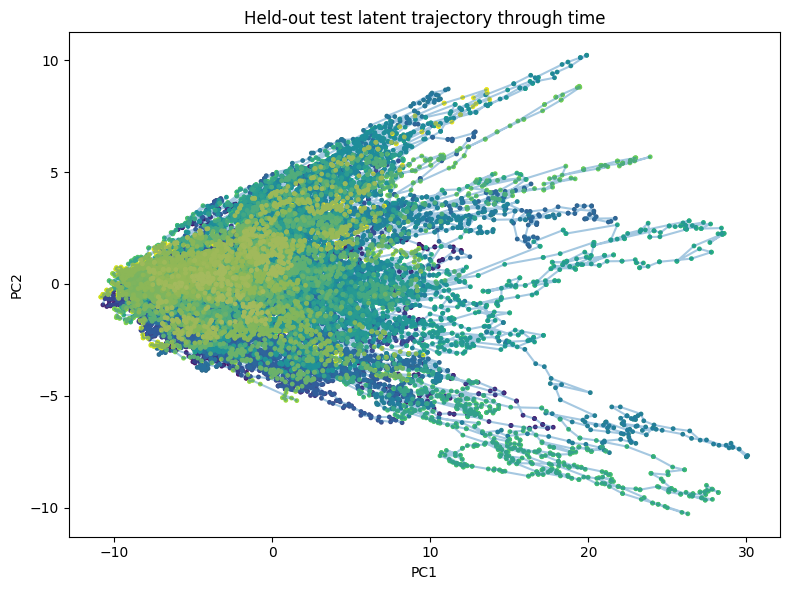

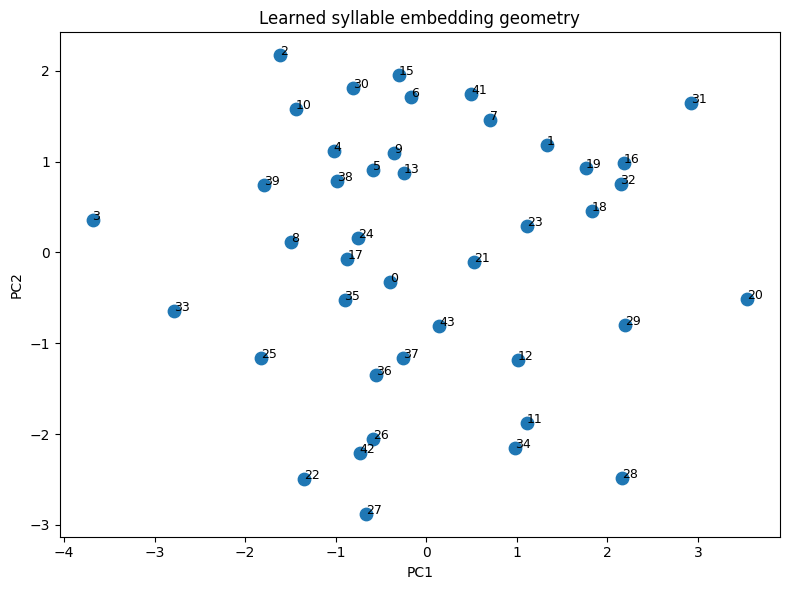

Done.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


class SyllablePCModel(nn.Module):
    def __init__(self, n_pcs, n_syllables, emb_dim=16, hidden_dim=128):
        super().__init__()

        self.syll_embedding = nn.Embedding(n_syllables, emb_dim)

        self.pc_encoder = nn.Sequential(
            nn.Linear(n_pcs, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim + emb_dim, hidden_dim),
            nn.ReLU(),
        )

        self.predict_next_pc = nn.Linear(hidden_dim, n_pcs)

    def forward(self, x_t, syll_t):
        e_t = self.syll_embedding(syll_t)          # [batch, emb_dim]
        h_t = self.pc_encoder(x_t)                 # [batch, hidden_dim]
        z_t = self.fusion(torch.cat([h_t, e_t], dim=-1))
        x_next_pred = self.predict_next_pc(z_t)
        return x_next_pred, z_t, e_t


def make_teacher_forced_split(neural_pcs, syllables_idx, train_frac=0.75):
    """
    Builds one-step transitions:
        input  : (x_t, syll_t)
        target : x_{t+1}

    Then splits transitions in time order:
        first 75% -> train
        last  25% -> test
    """
    T = len(neural_pcs)
    assert len(syllables_idx) == T

    x_t = neural_pcs[:-1].astype(np.float32)          # shape [T-1, n_pcs]
    x_tp1 = neural_pcs[1:].astype(np.float32)         # shape [T-1, n_pcs]
    syll_t = syllables_idx[:-1].astype(np.int64)      # shape [T-1]

    n_transitions = len(x_t)
    split_idx = int(train_frac * n_transitions)

    data = {
        "train": {
            "x_t": x_t[:split_idx],
            "syll_t": syll_t[:split_idx],
            "x_tp1": x_tp1[:split_idx],
        },
        "test": {
            "x_t": x_t[split_idx:],
            "syll_t": syll_t[split_idx:],
            "x_tp1": x_tp1[split_idx:],
        },
        "split_idx": split_idx,
    }
    return data


def to_torch(split_dict, device):
    return {
        "x_t": torch.tensor(split_dict["x_t"], dtype=torch.float32, device=device),
        "syll_t": torch.tensor(split_dict["syll_t"], dtype=torch.long, device=device),
        "x_tp1": torch.tensor(split_dict["x_tp1"], dtype=torch.float32, device=device),
    }


def evaluate_teacher_forced(model, x_t, syll_t, x_tp1, loss_fn):
    model.eval()
    with torch.no_grad():
        pred, z_t, e_t = model(x_t, syll_t)
        loss = loss_fn(pred, x_tp1).item()
    return {
        "loss": loss,
        "pred": pred.cpu().numpy(),
        "true": x_tp1.cpu().numpy(),
        "z": z_t.cpu().numpy(),
        "e": e_t.cpu().numpy(),
    }


def visualize_predictions(true, pred, title_prefix="Test", max_points=300, n_plot_pcs=3):
    n_pcs = true.shape[1]
    n_plot_pcs = min(n_plot_pcs, n_pcs)
    n_show = min(max_points, len(true))

    for pc_idx in range(n_plot_pcs):
        plt.figure(figsize=(10, 4))
        plt.plot(true[:n_show, pc_idx], label=f"true PC{pc_idx + 1}")
        plt.plot(pred[:n_show, pc_idx], label=f"pred PC{pc_idx + 1}")
        plt.title(f"{title_prefix}: next-step teacher-forced prediction for PC{pc_idx + 1}")
        plt.legend()
        plt.tight_layout()
        plt.show()


def visualize_test_latent_space(model, test_split, device):
    """
    Visualize latent z_t only on the held-out test segment.
    """
    model.eval()

    x_t = torch.tensor(test_split["x_t"], dtype=torch.float32, device=device)
    syll_t = torch.tensor(test_split["syll_t"], dtype=torch.long, device=device)

    with torch.no_grad():
        _, z_t, e_t = model(x_t, syll_t)

    z_np = z_t.cpu().numpy()
    e_np = e_t.cpu().numpy()
    syll_t_np = test_split["syll_t"]

    z_2d = PCA(n_components=2).fit_transform(z_np)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        z_2d[:, 0],
        z_2d[:, 1],
        c=syll_t_np,
        s=8,
        alpha=0.7,
    )
    plt.colorbar(sc, label="syllable index")
    plt.title("Held-out test latent state z_t (PCA), colored by syllable")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(z_2d[:, 0], z_2d[:, 1], alpha=0.4)
    plt.scatter(z_2d[:, 0], z_2d[:, 1], c=np.arange(len(z_2d)), s=6)
    plt.title("Held-out test latent trajectory through time")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    # Since embeddings are fixed per syllable id, just read them directly
    unique_ids = np.unique(syll_t_np)
    emb_table = model.syll_embedding.weight.detach().cpu().numpy()
    syll_emb = emb_table[unique_ids]

    syll_emb_2d = PCA(n_components=2).fit_transform(syll_emb)

    plt.figure(figsize=(8, 6))
    plt.scatter(syll_emb_2d[:, 0], syll_emb_2d[:, 1], s=80)
    for i, label in enumerate(unique_ids):
        plt.text(syll_emb_2d[i, 0], syll_emb_2d[i, 1], str(label), fontsize=9)

    plt.title("Learned syllable embedding geometry")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    return z_np, z_2d, e_np


def main():
    # -------------------------
    # Load data
    # -------------------------
    neural = np.load('/home/maria/Science/data/spontaneous_behaviors/made_data/neural_rec.npy')
    syllables = np.load('/home/maria/Science/data/spontaneous_behaviors/made_data/moseq_syllables_aux.npy')

    print("Raw neural shape:", neural.shape)
    print("Raw syllables shape:", syllables.shape)

    if neural.ndim != 2:
        raise ValueError(f"Expected neural to have shape [T, n_neurons], got {neural.shape}")

    syllables = np.asarray(syllables).squeeze()
    if syllables.ndim != 1:
        raise ValueError(f"Expected syllables to have shape [T], got {syllables.shape}")

    if len(neural) != len(syllables):
        raise ValueError(
            f"Length mismatch: neural has {len(neural)} timepoints, "
            f"but syllables has {len(syllables)} entries"
        )

    # -------------------------
    # Remap syllables to 0...K-1
    # -------------------------
    unique_sylls = np.unique(syllables)
    syll_to_idx = {s: i for i, s in enumerate(unique_sylls)}
    syllables_idx = np.array([syll_to_idx[s] for s in syllables], dtype=np.int64)

    # -------------------------
    # Train/test split in time BEFORE scaling/PCA
    # -------------------------
    T = len(neural)
    train_time_end = int(0.75 * T)

    neural_train = neural[:train_time_end]
    neural_test = neural[train_time_end:]

    print("Train timepoints:", len(neural_train))
    print("Test timepoints:", len(neural_test))

    # -------------------------
    # Fit scaler/PCA ONLY on train segment
    # -------------------------
    scaler = StandardScaler()
    neural_train_scaled = scaler.fit_transform(neural_train)
    neural_test_scaled = scaler.transform(neural_test)

    n_pcs = 10
    pca = PCA(n_components=n_pcs)
    neural_train_pcs = pca.fit_transform(neural_train_scaled)
    neural_test_pcs = pca.transform(neural_test_scaled)

    neural_pcs = np.concatenate([neural_train_pcs, neural_test_pcs], axis=0)

    print("PC data shape:", neural_pcs.shape)
    print("Explained variance ratio (train PCA):", pca.explained_variance_ratio_)
    print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

    # -------------------------
    # Build one-step dataset and split transitions in time
    # -------------------------
    split_data = make_teacher_forced_split(
        neural_pcs=neural_pcs,
        syllables_idx=syllables_idx,
        train_frac=0.75,
    )

    print("Transition split index:", split_data["split_idx"])
    print("Train transitions:", len(split_data["train"]["x_t"]))
    print("Test transitions:", len(split_data["test"]["x_t"]))

    # -------------------------
    # Torch tensors
    # -------------------------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    train_torch = to_torch(split_data["train"], device)
    test_torch = to_torch(split_data["test"], device)

    # -------------------------
    # Model
    # -------------------------
    num_syllables = len(unique_sylls)

    model = SyllablePCModel(
        n_pcs=n_pcs,
        n_syllables=num_syllables,
        emb_dim=16,
        hidden_dim=128,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # -------------------------
    # Training on first 75% only
    # -------------------------
    n_epochs = 200
    train_losses = []
    test_losses = []

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()

        pred_train, _, _ = model(train_torch["x_t"], train_torch["syll_t"])
        train_loss = loss_fn(pred_train, train_torch["x_tp1"])

        train_loss.backward()
        optimizer.step()

        # teacher-forced out-of-sample evaluation
        model.eval()
        with torch.no_grad():
            pred_test, _, _ = model(test_torch["x_t"], test_torch["syll_t"])
            test_loss = loss_fn(pred_test, test_torch["x_tp1"])

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if epoch % 20 == 0 or epoch == n_epochs - 1:
            print(
                f"Epoch {epoch:03d} | "
                f"Train loss: {train_loss.item():.6f} | "
                f"Test loss (teacher forced): {test_loss.item():.6f}"
            )

    # -------------------------
    # Final evaluation
    # -------------------------
    train_eval = evaluate_teacher_forced(
        model,
        train_torch["x_t"],
        train_torch["syll_t"],
        train_torch["x_tp1"],
        loss_fn,
    )

    test_eval = evaluate_teacher_forced(
        model,
        test_torch["x_t"],
        test_torch["syll_t"],
        test_torch["x_tp1"],
        loss_fn,
    )

    print("\nFinal results")
    print("Train MSE:", train_eval["loss"])
    print("Test MSE (teacher forced, out of sample):", test_eval["loss"])

    # -------------------------
    # Baseline comparison
    # -------------------------
    baseline_train_pred = split_data["train"]["x_t"]
    baseline_test_pred = split_data["test"]["x_t"]

    baseline_train_mse = np.mean((baseline_train_pred - split_data["train"]["x_tp1"]) ** 2)
    baseline_test_mse = np.mean((baseline_test_pred - split_data["test"]["x_tp1"]) ** 2)

    print("Baseline train MSE (predict next PC = current PC):", baseline_train_mse)
    print("Baseline test MSE  (predict next PC = current PC):", baseline_test_mse)

    # -------------------------
    # Plot training curves
    # -------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="train loss")
    plt.plot(test_losses, label="test loss (teacher forced)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("Training vs out-of-sample teacher-forced test loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------
    # Plot held-out predictions
    # -------------------------
    visualize_predictions(
        true=test_eval["true"],
        pred=test_eval["pred"],
        title_prefix="Held-out test",
        max_points=300,
        n_plot_pcs=3,
    )

    # -------------------------
    # Visualize latent space on held-out segment
    # -------------------------
    visualize_test_latent_space(
        model=model,
        test_split=split_data["test"],
        device=device,
    )

    print("Done.")
    return model, pca, scaler, split_data, train_eval, test_eval


model, pca_model, scaler_model, split_data, train_eval, test_eval = main()